# IMDb Movie Reviews Sentiment Analysis Using RNN and LSTM Models

## Project Overview

This notebook implements a binary sentiment analysis project using the IMDb Movie Reviews dataset. Each review is labelled as either negative (`0`) or positive (`1`). The dataset contains highly polarised reviews only: negative reviews have scores less than or equal to 4 out of 10, while positive reviews have scores greater than or equal to 7 out of 10.

The main objective is to preprocess raw movie-review text, convert it into padded numerical sequences, train recurrent neural-network models, compare their performance, analyse errors, and build a simple real-time prediction interface.

The notebook follows the required task structure:

1. Text preprocessing, tokenization, and sequence padding
2. Model building and training
3. Model training and evaluation
4. Error analysis
5. GUI for real-time prediction


## Dataset Description

The IMDb Movie Reviews dataset is a binary sentiment analysis dataset containing movie reviews from the Internet Movie Database. Reviews are labelled as positive or negative.

- Positive sentiment is represented by label `1`.
- Negative sentiment is represented by label `0`.
- The dataset contains an even number of positive and negative reviews.
- Only highly polarised reviews are included.
- A negative review has a score less than or equal to 4 out of 10.
- A positive review has a score greater than or equal to 7 out of 10.
- No more than 30 reviews are included per movie.
- Any additional unlabeled data will be removed before modelling.

The dataset files are stored in Google Drive at:

`/content/drive/MyDrive/heraldlastsem/Ai/data`

The files used in this project are:

- `train_movie_review.csv`
- `val_movie_review.csv`
- `test_movie_review.csv`


# 4.5.1 Text Preprocessing, Tokenization, and Sequence Padding

In this section, the raw movie-review text is loaded, cleaned, explored visually, tokenized, and padded. The preprocessing steps include lowercasing, removing unwanted text patterns, handling contractions, removing stopwords, and lemmatizing words.

## Load Required Libraries

In [1]:
# Core libraries
import os
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine learning utilities
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Visualisation
from wordcloud import WordCloud

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## Download NLTK Resources

The following resources are required for stopword removal and lemmatization.

In [2]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Load the Dataset

The dataset is loaded from Google Drive using Pandas. The project already contains separate training, validation, and testing CSV files, so the original dataset split is preserved instead of creating a new random split.

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
DATA_DIR = Path("/content/drive/MyDrive/movie review/data")

train_data = pd.read_csv(DATA_DIR / "train_movie_review.csv")
val_data = pd.read_csv(DATA_DIR / "val_movie_review.csv")
test_data = pd.read_csv(DATA_DIR / "test_movie_review.csv")

print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)
print("Test shape:", test_data.shape)

display(train_data.head())


Train shape: (35000, 3)
Validation shape: (5000, 3)
Test shape: (10000, 3)


,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0


## Identify Text and Label Columns

This project expects one text column containing the review and one target column containing the sentiment label. The helper function below makes the notebook robust to common column names such as `review`, `text`, `sentiment`, and `label`.

In [5]:
def identify_text_and_label_columns(df):
    text_candidates = ["review", "text", "sentence", "content", "movie_review"]
    label_candidates = ["sentiment", "label", "target", "class"]

    columns_lower = {column.lower(): column for column in df.columns}

    text_column = None
    for candidate in text_candidates:
        if candidate in columns_lower:
            text_column = columns_lower[candidate]
            break

    if text_column is None:
        object_columns = df.select_dtypes(include=["object"]).columns.tolist()
        if object_columns:
            text_column = object_columns[0]

    label_column = None
    for candidate in label_candidates:
        if candidate in columns_lower:
            label_column = columns_lower[candidate]
            break

    if label_column is None:
        for column in df.columns:
            values = set(df[column].dropna().unique().tolist())
            if values.issubset({0, 1, "0", "1", "positive", "negative", "pos", "neg"}):
                label_column = column
                break

    if text_column is None or label_column is None:
        raise ValueError("Could not automatically identify text and label columns. Please set them manually.")

    return text_column, label_column


TEXT_COLUMN, LABEL_COLUMN = identify_text_and_label_columns(train_data)
print("Text column:", TEXT_COLUMN)
print("Label column:", LABEL_COLUMN)


Text column: review
Label column: sentiment


## Prepare Labelled Train, Validation, and Test Data

If any split contains extra unlabelled records, those rows are removed. The target labels are then converted into binary numeric form for each dataset separately.

In [6]:
# Standardise labels to 0 and 1.
label_mapping = {
    "negative": 0,
    "neg": 0,
    "0": 0,
    0: 0,
    "positive": 1,
    "pos": 1,
    "1": 1,
    1: 1,
}


def prepare_labelled_dataset(df, text_column, label_column, split_name):
    prepared_df = df[[text_column, label_column]].copy()
    prepared_df.columns = ["review", "sentiment"]
    prepared_df = prepared_df.dropna(subset=["review", "sentiment"])
    prepared_df["sentiment"] = prepared_df["sentiment"].map(
        lambda value: label_mapping.get(value, label_mapping.get(str(value).lower()))
    )
    prepared_df = prepared_df.dropna(subset=["sentiment"])
    prepared_df["sentiment"] = prepared_df["sentiment"].astype(int)
    prepared_df["review"] = prepared_df["review"].astype(str)
    prepared_df["split"] = split_name
    return prepared_df.reset_index(drop=True)


train_df = prepare_labelled_dataset(train_data, TEXT_COLUMN, LABEL_COLUMN, "train")
val_df = prepare_labelled_dataset(val_data, TEXT_COLUMN, LABEL_COLUMN, "validation")
test_df = prepare_labelled_dataset(test_data, TEXT_COLUMN, LABEL_COLUMN, "test")
all_data = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("Train labelled shape:", train_df.shape)
print("Validation labelled shape:", val_df.shape)
print("Test labelled shape:", test_df.shape)

display(pd.crosstab(all_data["split"], all_data["sentiment"]).rename(columns={0: "Negative", 1: "Positive"}))


Train labelled shape: (35000, 3)
Validation labelled shape: (5000, 3)
Test labelled shape: (10000, 3)


sentiment,Negative,Positive
split,,
test,4961,5039
train,17584,17416
validation,2455,2545


## Clean the Text

The following cleaning steps are applied to each review:

- Convert all text to lowercase.
- Handle contractions such as `don't` to `do not`.
- Remove URLs, mentions, hashtags, numbers, and special characters.
- Remove stopwords.
- Lemmatize words to reduce them to their base form.

In [7]:
contraction_map = {
    "aren't": "are not", "can't": "cannot", "couldn't": "could not",
    "didn't": "did not", "doesn't": "does not", "don't": "do not",
    "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
    "he'd": "he would", "he'll": "he will", "he's": "he is",
    "i'd": "i would", "i'll": "i will", "i'm": "i am", "i've": "i have",
    "isn't": "is not", "it's": "it is", "let's": "let us",
    "mustn't": "must not", "shan't": "shall not", "she'd": "she would",
    "she'll": "she will", "she's": "she is", "shouldn't": "should not",
    "that's": "that is", "there's": "there is", "they'd": "they would",
    "they'll": "they will", "they're": "they are", "they've": "they have",
    "wasn't": "was not", "we'd": "we would", "we're": "we are",
    "weren't": "were not", "what's": "what is", "won't": "will not",
    "wouldn't": "would not", "you'd": "you would", "you'll": "you will",
    "you're": "you are", "you've": "you have"
}

stop_words = set(stopwords.words("english")) - {"not", "no", "nor"}

lemmatizer = WordNetLemmatizer()


def expand_contractions(text):
    pattern = re.compile("|".join(re.escape(key) for key in contraction_map.keys()))
    return pattern.sub(lambda match: contraction_map[match.group(0)], text)

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)

    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep hashtag words
    text = re.sub(r"#", "", text)

    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = [word for word in text.split() if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)


for dataset in [train_df, val_df, test_df]:
    dataset["clean_review"] = dataset["review"].apply(clean_text)

train_df = train_df[train_df["clean_review"].str.len() > 0].reset_index(drop=True)
val_df = val_df[val_df["clean_review"].str.len() > 0].reset_index(drop=True)
test_df = test_df[test_df["clean_review"].str.len() > 0].reset_index(drop=True)

all_data = pd.concat([train_df, val_df, test_df], ignore_index=True)

display(train_df[["review", "clean_review", "sentiment"]].head())

,review,clean_review,sentiment
0,"Having avoided seeing the movie in the cinema,...",avoided seeing movie cinema buying dvd wife xm...,0
1,With this movie I was really hoping that the i...,movie really hoping idea make hashed together ...,0
2,Raymond Burr stars as an attorney caught up in...,raymond burr star attorney caught murder best ...,0
3,A lot people get hung up on this films tag as ...,lot people get hung film tag child film certai...,1
4,I was a fan of Buffy and hoped it would come t...,fan buffy hoped would come proper end angel go...,0


In [8]:
print(f"'not' in stop_words: {'not' in stop_words}")
print(f"'good' in stop_words: {'good' in stop_words}")


'not' in stop_words: False
'good' in stop_words: False


## Visualize the Cleaned Data

A word cloud and a most-frequent-words bar chart are used to explore the cleaned movie-review text.

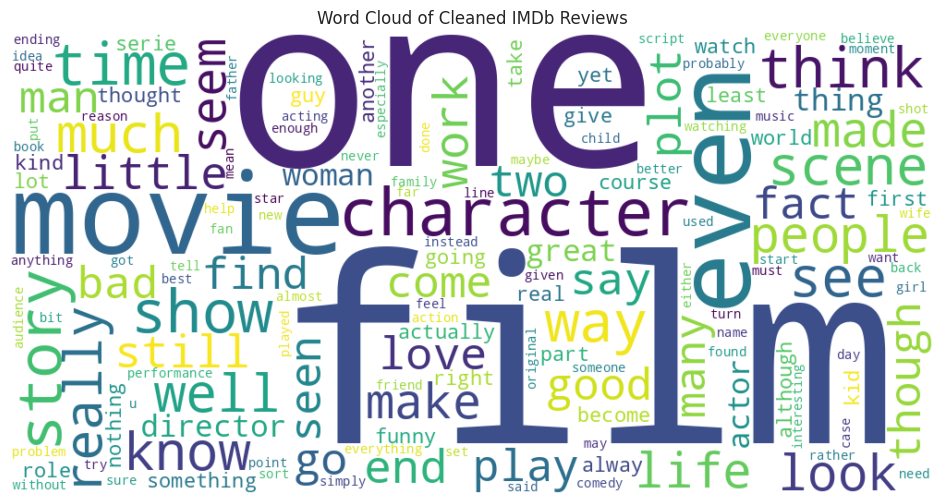

In [9]:
clean_text_corpus = " ".join(all_data["clean_review"].tolist())

wordcloud = WordCloud(width=1000, height=500, background_color="white", max_words=150).generate(clean_text_corpus)
plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned IMDb Reviews")
plt.show()


/tmp/ipykernel_24149/3664929661.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_frequencies.values, y=word_frequencies.index, palette="viridis")


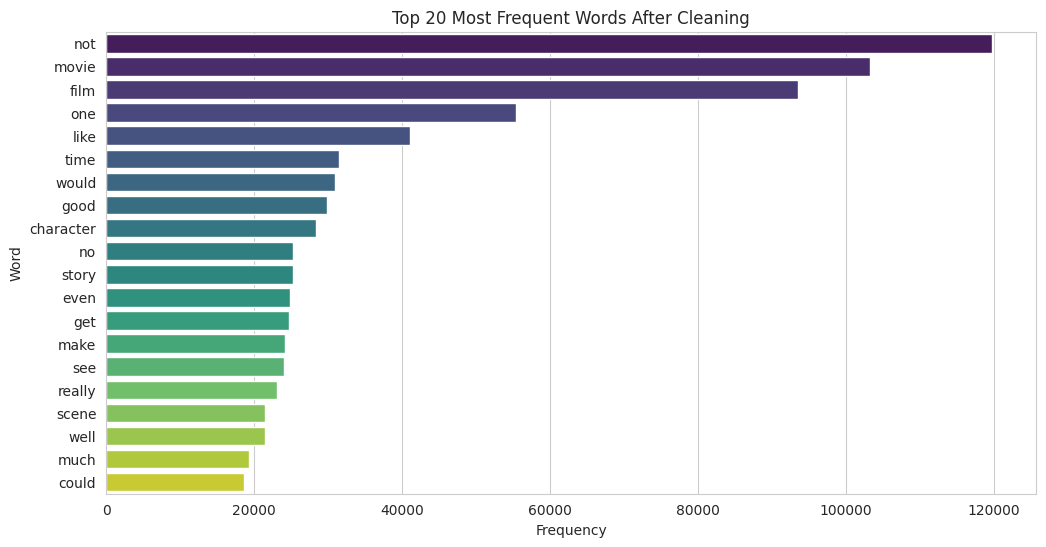

In [10]:
word_frequencies = pd.Series(" ".join(all_data["clean_review"]).split()).value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=word_frequencies.values, y=word_frequencies.index, palette="viridis")
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()


## Tokenization and Padding Using the Provided Splits

The Keras Tokenizer is fitted only on the cleaned training text to avoid data leakage. The same tokenizer is then applied to the validation and test sets. Padding is applied using a percentile-based maximum sequence length calculated from the training sequences to avoid excessively long sequences.

In [11]:
X_train_text = train_df["clean_review"]
y_train = train_df["sentiment"].values

X_val_text = val_df["clean_review"]
y_val = val_df["sentiment"].values

X_test_text = test_df["clean_review"]
y_test = test_df["sentiment"].values

VOCAB_SIZE = 20000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

train_sequences = tokenizer.texts_to_sequences(X_train_text)
val_sequences = tokenizer.texts_to_sequences(X_val_text)
test_sequences = tokenizer.texts_to_sequences(X_test_text)

sequence_lengths = [len(sequence) for sequence in train_sequences]
MAX_SEQUENCE_LENGTH = int(np.percentile(sequence_lengths, 95))
MAX_SEQUENCE_LENGTH = max(MAX_SEQUENCE_LENGTH, 20)

X_train = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
X_val = pad_sequences(val_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
X_test = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")

vocab_size = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Testing samples:", X_test.shape[0])
print("Vocabulary size:", vocab_size)
print("95th percentile max sequence length:", MAX_SEQUENCE_LENGTH)


Training samples: 35000
Validation samples: 5000
Testing samples: 10000
Vocabulary size: 20000
95th percentile max sequence length: 312


# 4.5.2 Model Building and Training

Three models are built for binary text classification:

1. Simple RNN with a trainable Embedding layer.
2. LSTM with a trainable Embedding layer.
3. LSTM with pretrained Word2Vec-style GloVe embeddings.

## Shared Model Settings

In [12]:
EMBEDDING_DIM = 50
BATCH_SIZE = 64
EPOCHS = 10

def get_callbacks():
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )

    return [early_stopping, reduce_lr]


## Model 1: Simple RNN with Trainable Embedding Layer

This model uses a trainable Embedding layer followed by a SimpleRNN layer and a sigmoid output layer for binary sentiment classification.

In [13]:
def build_simple_rnn_model():
    model = Sequential(name="Simple_RNN_Trainable_Embedding")

    # input_shape fixes "0 params / unbuilt model" issue
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        input_shape=(MAX_SEQUENCE_LENGTH,),
        mask_zero=True
    ))

    model.add(SimpleRNN(64))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation="sigmoid"))

    return model


model_1 = build_simple_rnn_model()

model_1.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_1.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Simple_RNN_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 312, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         7,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,007,425 (3.84 MB)

 Trainable params: 1,007,425 (3.84 MB)

 Non-trainable params: 0 (0.00 B)

## Model 2: LSTM with Trainable Embedding Layer

This model uses a trainable Embedding layer followed by an LSTM layer. LSTM is expected to capture longer-term dependencies better than a SimpleRNN.

In [14]:
def build_lstm_model():
    model = Sequential(name="LSTM_Trainable_Embedding")

    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        input_shape=(MAX_SEQUENCE_LENGTH,),
        mask_zero=True
    ))

    model.add(Bidirectional(LSTM(64)))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation="sigmoid"))

    return model


model_2 = build_lstm_model()

model_2.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_2.summary()


Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 312, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        58,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,059,009 (4.04 MB)

 Trainable params: 1,059,009 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

## Model 3: LSTM with Pretrained Word2Vec Embeddings

This model uses pretrained embeddings loaded through `gensim`. Following the assignment appendix, `glove-wiki-gigaword-50` is used as a 50-dimensional pretrained embedding model.

In [15]:
import gensim.downloader as api

embedding_model = api.load("glove-wiki-gigaword-50")

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
word_index = tokenizer.word_index

for word, index in word_index.items():
    if index >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[index] = embedding_model[word]

print("Embedding matrix shape:", embedding_matrix.shape)


Embedding matrix shape: (20000, 50)


In [16]:
def build_lstm_pretrained_model():
    model = Sequential(name="BiLSTM_Pretrained_GloVe_Embedding")

    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_shape=(MAX_SEQUENCE_LENGTH,),
        trainable=True, # Changed to True for fine-tuning
        mask_zero=True
    ))

    model.add(Bidirectional(LSTM(64)))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation="sigmoid"))

    return model


model_3 = build_lstm_pretrained_model()

model_3.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_3.summary()


Model: "BiLSTM_Pretrained_GloVe_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 312, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        58,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,059,009 (4.04 MB)

 Trainable params: 1,059,009 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

# 4.5.3 Model Training and Evaluation

The models are compiled with binary cross-entropy loss, Adam optimizer, and accuracy as the main metric. Early stopping is used to reduce overfitting and restore the best validation weights.

## Train the Models

In [17]:
history_1 = model_1.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=1
)


Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.7777 - loss: 0.4667 - val_accuracy: 0.7416 - val_loss: 0.5241 - learning_rate: 0.0010
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.8877 - loss: 0.2906 - val_accuracy: 0.8334 - val_loss: 0.3778 - learning_rate: 0.0010
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.9320 - loss: 0.1897 - val_accuracy: 0.8366 - val_loss: 0.4050 - learning_rate: 0.0010
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.9595 - loss: 0.1181 - val_accuracy: 0.8620 - val_loss: 0.4661 - learning_rate: 0.0010
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.9825 - loss: 0.0537 - val_accuracy: 0.8614 - val_loss: 0.5028 - learning_rate: 5.0000e-04


In [18]:
history_2 = model_2.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=1
)


Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.8282 - loss: 0.3872 - val_accuracy: 0.8908 - val_loss: 0.2762 - learning_rate: 0.0010
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9267 - loss: 0.1986 - val_accuracy: 0.8858 - val_loss: 0.3004 - learning_rate: 0.0010
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.9551 - loss: 0.1315 - val_accuracy: 0.8768 - val_loss: 0.3393 - learning_rate: 0.0010
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.9771 - loss: 0.0740 - val_accuracy: 0.8810 - val_loss: 0.4025 - learning_rate: 5.0000e-04


In [19]:
history_3 = model_3.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=1
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.8011 - loss: 0.4202 - val_accuracy: 0.8708 - val_loss: 0.3071 - learning_rate: 0.0010
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.8973 - loss: 0.2570 - val_accuracy: 0.8910 - val_loss: 0.2691 - learning_rate: 0.0010
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.9281 - loss: 0.1931 - val_accuracy: 0.8798 - val_loss: 0.2936 - learning_rate: 0.0010
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.9481 - loss: 0.1462 - val_accuracy: 0.8794 - val_loss: 0.3351 - learning_rate: 0.0010
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.9670 - loss: 0.0986 - val_accuracy: 0.8964 - val_loss: 0.3540 - learning_rate: 5.0000e-04


## Visualize Training vs Validation Loss and Accuracy

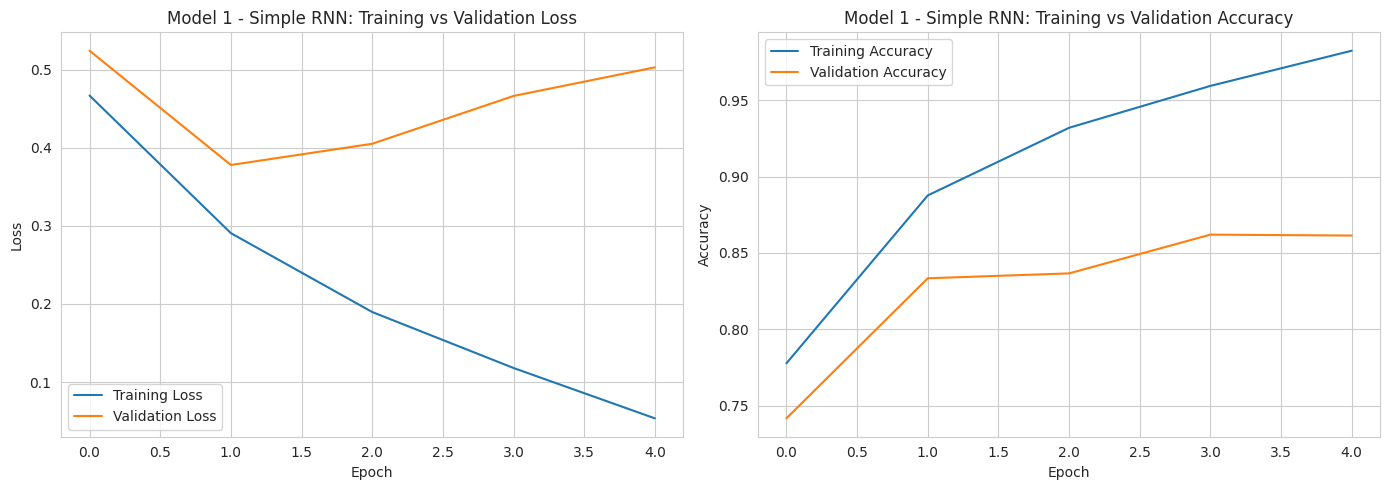

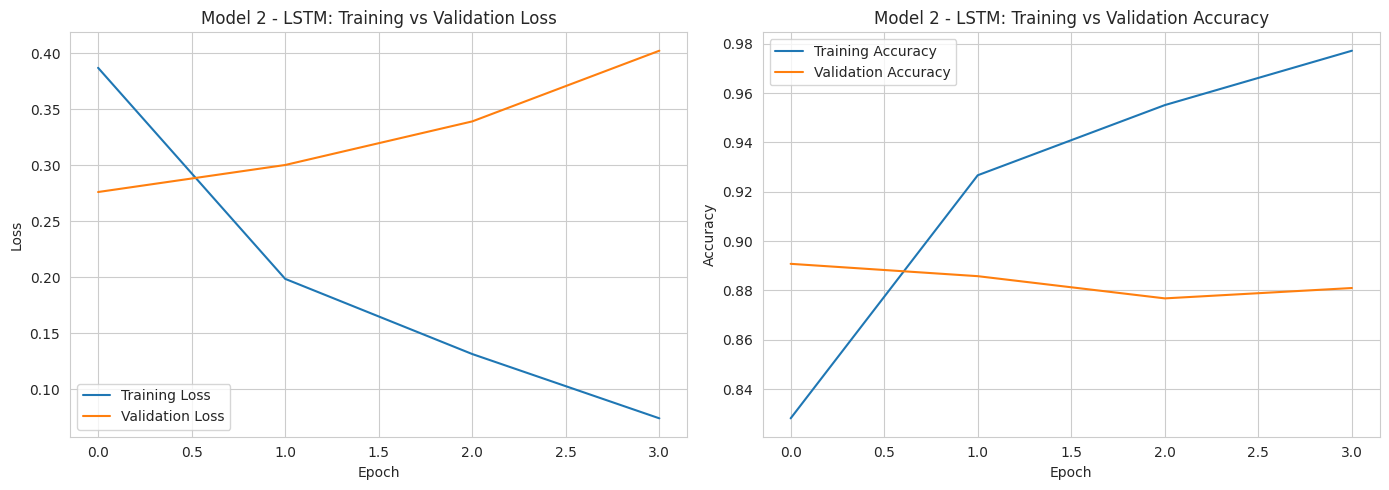

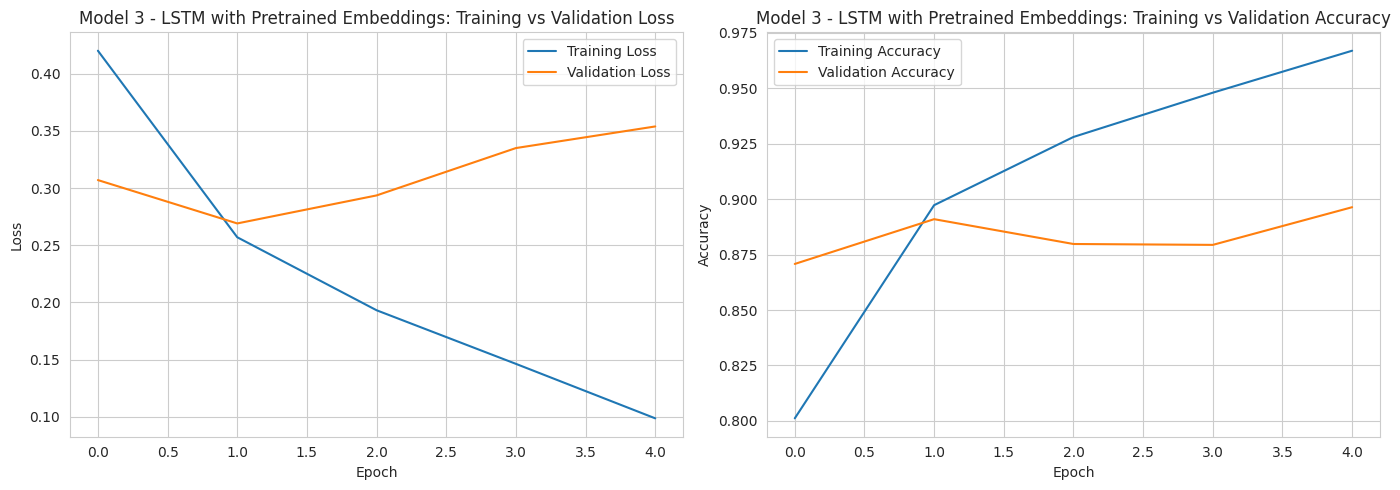

In [20]:
def plot_training_history(history, model_name):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_df["loss"], label="Training Loss")
    axes[0].plot(history_df["val_loss"], label="Validation Loss")
    axes[0].set_title(f"{model_name}: Training vs Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history_df["accuracy"], label="Training Accuracy")
    axes[1].plot(history_df["val_accuracy"], label="Validation Accuracy")
    axes[1].set_title(f"{model_name}: Training vs Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_training_history(history_1, "Model 1 - Simple RNN")
plot_training_history(history_2, "Model 2 - LSTM")
plot_training_history(history_3, "Model 3 - LSTM with Pretrained Embeddings")


## Evaluate the Models

Each model is evaluated using accuracy, confusion matrix, and classification report.

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Model 1 - Simple RNN Accuracy: 0.8377

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.80      0.83      4961
    Positive       0.82      0.87      0.84      5039

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



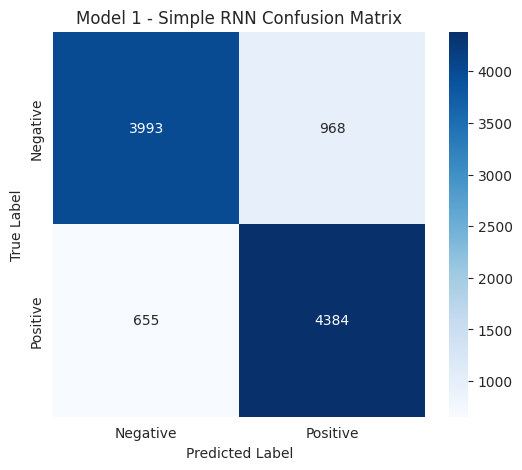

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Model 2 - LSTM Accuracy: 0.8892

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89      4961
    Positive       0.89      0.89      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



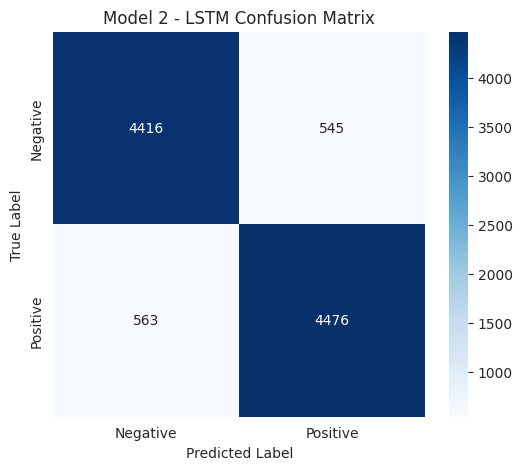

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Model 3 - LSTM with Pretrained Embeddings Accuracy: 0.8892

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      4961
    Positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



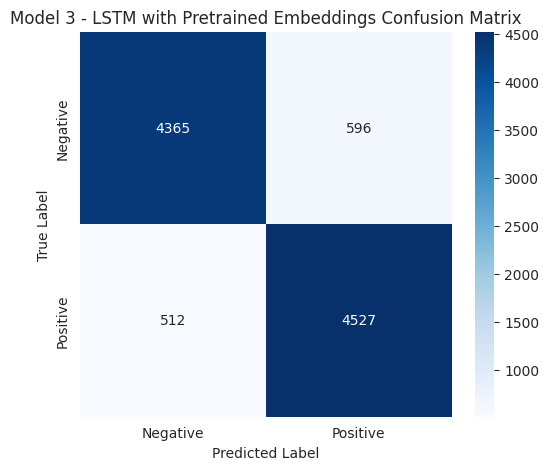

In [21]:
def evaluate_model(model, X_test, y_test, model_name):
    probabilities = model.predict(X_test).ravel()
    predictions = (probabilities >= 0.5).astype(int)
    accuracy = accuracy_score(y_test, predictions)

    print(f"{model_name} Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, predictions, target_names=["Negative", "Positive"]))

    matrix = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    return {
        "model_name": model_name,
        "accuracy": accuracy,
        "probabilities": probabilities,
        "predictions": predictions
    }


results_1 = evaluate_model(model_1, X_test, y_test, "Model 1 - Simple RNN")
results_2 = evaluate_model(model_2, X_test, y_test, "Model 2 - LSTM")
results_3 = evaluate_model(model_3, X_test, y_test, "Model 3 - LSTM with Pretrained Embeddings")

## Compare Model 1 vs Model 2 vs Model 3

,Model,Accuracy
0,Model 1 - Simple RNN,0.8377
1,Model 2 - LSTM,0.8892
2,Model 3 - LSTM with Pretrained Embeddings,0.8892


/tmp/ipykernel_24149/3895967634.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x="Accuracy", y="Model", palette="mako")


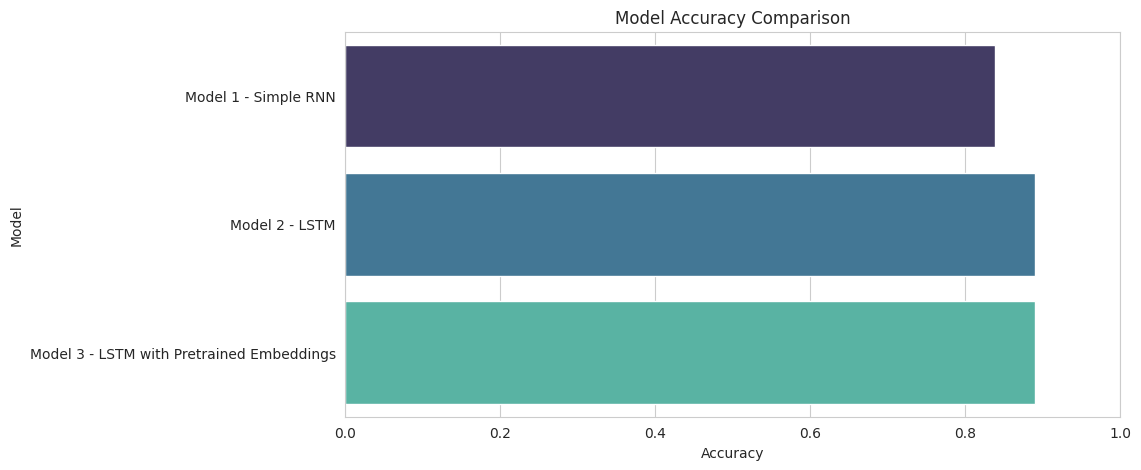

In [22]:
comparison_df = pd.DataFrame([
    {"Model": results_1["model_name"], "Accuracy": results_1["accuracy"]},
    {"Model": results_2["model_name"], "Accuracy": results_2["accuracy"]},
    {"Model": results_3["model_name"], "Accuracy": results_3["accuracy"]},
])

display(comparison_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="Accuracy", y="Model", palette="mako")
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)
plt.show()

# 4.5.4 Error Analysis

This section analyses misclassified examples, evaluates model complexity versus performance, explains possible reasons for error, and suggests improvements.

## Analyse Misclassified Examples

The best-performing model is selected based on test accuracy. Then 2 to 3 incorrect predictions are displayed for qualitative analysis.

In [23]:
all_results = [results_1, results_2, results_3]
best_result = max(all_results, key=lambda item: item["accuracy"])
best_model_name = best_result["model_name"]

error_df = pd.DataFrame({
    "clean_review": X_test_text,
    "actual_label": y_test,
    "predicted_label": best_result["predictions"],
    "predicted_probability": best_result["probabilities"]
})

misclassified_examples = error_df[error_df["actual_label"] != error_df["predicted_label"]].copy()

print("Best model:", best_model_name)
print("Number of misclassified examples:", len(misclassified_examples))
display(misclassified_examples.head(3))


Best model: Model 2 - LSTM
Number of misclassified examples: 1108


,clean_review,actual_label,predicted_label,predicted_probability
0,really liked summerslam due look arena curtain...,1,0,0.045599
7,okay not get purgatory thing first time watche...,1,0,0.047556
15,movie start somewhat slowly get running toward...,1,0,0.231087


## Model Complexity vs Performance

Model 1 uses a SimpleRNN layer, which is less complex and faster to train, but it may struggle to capture long-range word dependencies in movie reviews. Model 2 uses an LSTM layer, which is more complex and better suited to longer sequences because it can preserve useful information through gated memory. Model 3 also uses LSTM, but its Embedding layer is initialized with pretrained GloVe embeddings. This can improve generalization when the dataset is limited, although frozen pretrained embeddings may not always match the exact language style of IMDb reviews.

The best model should be selected by comparing validation behaviour and test-set accuracy, not by complexity alone. If a more complex model improves test accuracy without a large validation gap, the additional complexity is justified. If the validation loss increases while training accuracy improves, the model may be overfitting.

## Possible Reasons for Incorrect Predictions

The model may make incorrect predictions for the following reasons:

- Some reviews contain sarcasm or indirect sentiment that is difficult to detect from individual words.
- Very long reviews may lose important context after percentile-based truncation.
- Some reviews contain mixed opinions, where positive and negative phrases appear together.
- Stopword removal may remove words that are useful for sentiment, especially negation-related words.
- Pretrained embeddings may not fully capture domain-specific movie-review expressions.

## Potential Improvements

Possible improvements include:

- Keep important negation words such as `not`, `no`, and `never` during preprocessing.
- Tune hyperparameters such as embedding dimension, LSTM units, dropout rate, batch size, and learning rate.
- Use bidirectional LSTM to capture both left and right context.
- Fine-tune pretrained embeddings by setting `trainable=True` after initial training.
- Try stronger pretrained language models such as BERT for deeper contextual understanding.
- Use cross-validation or a separate validation file for more reliable model selection.

# 4.5.5 GUI for Real Time Prediction

A simple Gradio interface is created to allow a user to enter a movie review and receive a real-time sentiment prediction from the best-performing model.

In [24]:

!pip install gradio


In [25]:
model_lookup = {
    results_1["model_name"]: model_1,
    results_2["model_name"]: model_2,
    results_3["model_name"]: model_3,
}
best_model = model_lookup[best_model_name]


def predict_sentiment(review_text):
    cleaned_review = clean_text(review_text)
    sequence = tokenizer.texts_to_sequences([cleaned_review])
    padded_sequence = pad_sequences(sequence, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
    probability = float(best_model.predict(padded_sequence, verbose=0).ravel()[0])
    label = "Positive" if probability >= 0.5 else "Negative"
    confidence = probability if label == "Positive" else 1 - probability
    return f"Prediction: {label}\nConfidence: {confidence:.2%}\nPositive probability: {probability:.2%}"


predict_sentiment("This movie was emotional, beautifully acted, and completely unforgettable.")


'Prediction: Positive\nConfidence: 87.03%\nPositive probability: 87.03%'

In [26]:
import gradio as gr

interface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=6, placeholder="Enter a movie review here...", label="Movie Review"),
    outputs=gr.Textbox(label="Sentiment Prediction"),
    title="IMDb Movie Review Sentiment Prediction",
    description="Enter a movie review to predict whether the sentiment is positive or negative."
)

interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://45d773aa69c14df381.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Conclusion

This project completed the required binary sentiment-analysis workflow for IMDb movie reviews. The raw text was cleaned, tokenized, padded, and used to train three recurrent neural-network models. The models were evaluated using accuracy, confusion matrix, and classification report. Their training behaviour was visualized, misclassified examples were analysed, and a Gradio interface was created for real-time sentiment prediction.